In [ ]:
# ===== Cell 1 =====
# This cell installs the external Python libraries required for the project.

# Import subprocess module
# subprocess allows Python to run system/terminal commands from inside a script
import subprocess

# Run a system command using subprocess
# Here we run the pip command to install required libraries
subprocess.run(
    [
        "pip",       # Python package manager used to install libraries
        "install",   # pip command to install packages
        "-q",        # quiet mode → reduces installation output messages
        "gradio",    # library used to create simple web interfaces for ML/AI apps
        "pyttsx3"    # library used for text-to-speech (converts text into voice)
    ],
    check=False     # if installation fails, the program will not stop with an error
)

CompletedProcess(args=['pip', 'install', '-q', 'gradio', 'pyttsx3'], returncode=0)

In [ ]:
# ===== Cell 2 =====
# This cell imports all required libraries and sets the computing device (CPU or GPU)

import os
# os module is used for operating system related tasks like file paths and directories

import warnings
# warnings module is used to control warning messages during program execution

warnings.filterwarnings("ignore")
# This hides warning messages to keep the output clean

import numpy as np
# NumPy is used for numerical operations and working with arrays

import matplotlib.pyplot as plt
# Matplotlib is used for plotting graphs and visualizing results

from PIL import Image
# PIL (Python Imaging Library) is used to open, process, and manipulate images

import torch
# PyTorch main library used for deep learning and tensor operations

import torch.nn as nn
# nn module provides classes to build neural network layers

import torch.optim as optim
# optim module provides optimization algorithms like SGD and Adam

from torch.utils.data import Dataset, DataLoader, Subset
# Dataset → defines custom datasets
# DataLoader → loads data in batches during training
# Subset → selects a part of a dataset

import torchvision.transforms as T
# transforms are used for image preprocessing (resize, normalize, etc.)

from torchvision.datasets import OxfordIIITPet
# OxfordIIITPet is a built-in dataset containing images of cats and dogs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# This checks if a GPU (CUDA) is available
# If available → use GPU
# Otherwise → use CPU

print(f"Using device: {device}")
# Displays which device (CPU or GPU) will be used for computation

Using device: cpu


In [ ]:
# ===== Cell 3 =====
# Define hyperparameters and image transformations

IMG_SIZE = 128
# Size to which all images and masks will be resized (128 × 128 pixels)

SUBSET = 250
# Number of images taken from the dataset for training/testing

TRAIN_FRAC = 0.8
# 80% of data will be used for training and 20% for testing

EPOCHS = 5
# Number of times the model will pass through the entire training dataset

LR = 1e-3
# Learning rate for the optimizer (controls how fast the model learns)

BATCH = 16
# Number of images processed together in one training step

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
# Mean and standard deviation used to normalize image pixel values

img_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    # Resize input images to 128 × 128

    T.ToTensor(),
    # Convert image into PyTorch tensor format

    T.Normalize(mean=MEAN, std=STD),
    # Normalize image values for better model training
])

mask_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST),
    # Resize segmentation masks using nearest neighbor interpolation
    # This keeps class labels intact
])

In [ ]:
# ===== Cell 4 =====
# Create a custom dataset class using the OxfordIIITPet dataset
# The original dataset provides images and segmentation masks

# Original mask labels:
# 1 = pet
# 2 = background
# 3 = border

# For this project we convert it into binary segmentation:
# background (2) → walkable area (1)
# pet (1) and border (3) → obstacle (0)

class PetSegDataset(Dataset):

    def __init__(self):
        # Load OxfordIIITPet dataset with segmentation masks
        self.base = OxfordIIITPet(
            root="./data",             # folder where dataset will be stored
            split="trainval",          # use training + validation data
            target_types="segmentation", # load segmentation masks
            download=True,             # download dataset if not already present
        )

    def __len__(self):
        # Returns total number of samples in dataset
        return len(self.base)

    def __getitem__(self, idx):
        # Get image and mask at given index
        img, mask = self.base[idx]

        # Apply preprocessing transforms to image
        img = img_transform(img)

        # Apply resizing transform to mask
        mask = mask_transform(mask)

        # Convert mask to NumPy array
        mask_np = np.array(mask, dtype=np.int32)

        # Convert mask to binary segmentation
        # background (2) = 1 → walkable
        # pet/border (1,3) = 0 → obstacle
        binary = (mask_np == 2).astype(np.float32)

        # Convert to PyTorch tensor and add channel dimension
        # shape becomes [1, Height, Width]
        binary = torch.tensor(binary).unsqueeze(0)

        # Return processed image and binary mask
        return img, binary


# Create dataset object
full_ds = PetSegDataset()

# Print total number of images in dataset
print(f"Total dataset size: {len(full_ds)}")

100%|██████████| 792M/792M [00:22<00:00, 35.3MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 18.0MB/s]


Total dataset size: 3680


In [ ]:
# ===== Cell 5 =====
# Select a subset of dataset and split it into training and validation sets

torch.manual_seed(42)
# Sets random seed so that results are reproducible (same random selection every run)

indices = torch.randperm(len(full_ds))[:SUBSET].tolist()
# Randomly shuffle dataset indices and select only SUBSET number of samples

train_n = int(SUBSET * TRAIN_FRAC)
# Calculate number of training samples (80% of subset)

val_n = SUBSET - train_n
# Remaining samples used for validation

train_ds = Subset(full_ds, indices[:train_n])
# Create training dataset using selected indices

val_ds = Subset(full_ds, indices[train_n:])
# Create validation dataset using remaining indices

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
# DataLoader loads training data in batches and shuffles it for better learning

val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0)
# DataLoader for validation data (no shuffling needed)

print(f"Train: {train_n}  |  Val: {val_n}")
# Print number of training and validation samples

Train: 200  |  Val: 50


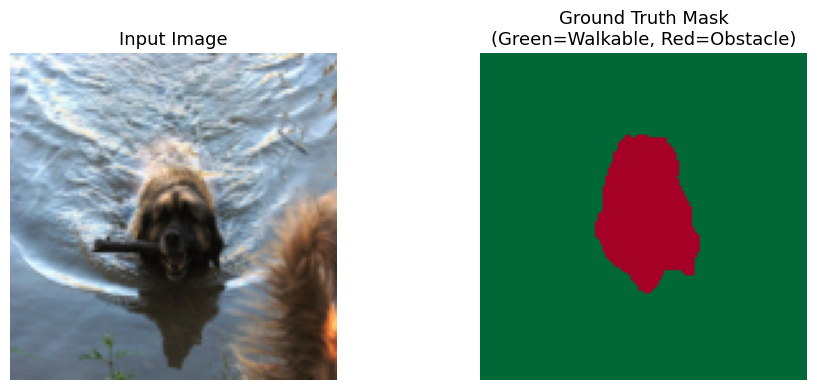

In [ ]:
# ===== Cell 6 =====
# Visualize one sample image and its segmentation mask before training

def denorm(t):
    """Reverse ImageNet normalization so the image looks normal when displayed"""

    m = torch.tensor(MEAN).view(3, 1, 1)
    # Convert mean values into tensor and reshape for broadcasting

    s = torch.tensor(STD).view(3, 1, 1)
    # Convert standard deviation values into tensor

    return (t * s + m).clamp(0, 1).permute(1, 2, 0).numpy()
    # Reverse normalization, limit pixel values between 0 and 1
    # Change tensor shape from (C,H,W) → (H,W,C) for display
    # Convert tensor to NumPy array for matplotlib

img_s, mask_s = full_ds[indices[0]]
# Get one sample image and its mask from the dataset

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Create a figure with two plots (image and mask)

axes[0].imshow(denorm(img_s))
# Display the input image after reversing normalization

axes[0].set_title("Input Image", fontsize=13)
axes[0].axis("off")
# Set title and remove axis lines

axes[1].imshow(mask_s.squeeze().numpy(), cmap="RdYlGn", vmin=0, vmax=1)
# Display the segmentation mask
# squeeze() removes extra dimension
# cmap shows colors (green = walkable, red = obstacle)

axes[1].set_title("Ground Truth Mask\n(Green=Walkable, Red=Obstacle)", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
# Adjust spacing between plots

plt.show()
# Display the final visualization

In [ ]:
# ===== Cell 7 =====
# Define a lightweight U-Net model for image segmentation

def conv_block(in_ch, out_ch):
    # A convolution block used repeatedly in U-Net
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        # 2D convolution layer (extracts features from image)

        nn.BatchNorm2d(out_ch),
        # Batch normalization improves training stability

        nn.ReLU(inplace=True),
        # ReLU activation introduces non-linearity

        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        # Second convolution layer for deeper feature extraction

        nn.BatchNorm2d(out_ch),
        # Normalize feature maps

        nn.ReLU(inplace=True),
        # Activation function
    )

class SmallUNet(nn.Module):
    # Define the U-Net neural network architecture

    def __init__(self):
        super().__init__()

        # Encoder (downsampling path)
        self.enc1 = conv_block(3, 16)
        # First encoder block (input image has 3 channels RGB)

        self.enc2 = conv_block(16, 32)
        # Second encoder block

        self.pool = nn.MaxPool2d(2)
        # Max pooling reduces spatial size (downsampling)

        self.bottleneck = conv_block(32, 64)
        # Bottleneck layer captures deeper features

        # Decoder (upsampling path)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        # Transposed convolution used for upsampling

        self.dec2 = conv_block(64, 32)
        # Decoder block (concatenates skip connection features)

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        # Second upsampling layer

        self.dec1 = conv_block(32, 16)
        # Final decoder block

        self.out = nn.Conv2d(16, 1, 1)
        # Output layer produces segmentation mask (1 channel)

    def forward(self, x):
        # Forward pass defines how data flows through the network

        e1 = self.enc1(x)
        # First encoder output

        e2 = self.enc2(self.pool(e1))
        # Downsample then apply second encoder

        b = self.bottleneck(self.pool(e2))
        # Bottleneck features

        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        # Upsample and concatenate skip connection from encoder

        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        # Final decoder with skip connection

        return self.out(d1)
        # Output segmentation logits with shape [Batch, 1, Height, Width]

# Create model and move it to selected device (CPU or GPU)
model = SmallUNet().to(device)

# Print total number of trainable parameters in the model
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 117,681


In [ ]:
# ===== Cell 8 =====
# Metric helpers and evaluation function

def pixel_accuracy(logits, targets):
    preds = (torch.sigmoid(logits) > 0.5).float()
    return (preds == targets).sum().item() / targets.numel()

def iou_score(logits, targets, eps=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float()
    inter = (preds * targets).sum().item()
    union = (preds + targets - preds * targets).sum().item()
    return inter / (union + eps)

criterion = nn.BCEWithLogitsLoss()

def evaluate(mdl, loader):
    mdl.eval()
    tot_loss = tot_acc = tot_iou = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out       = mdl(imgs)
            tot_loss += criterion(out, masks).item()
            tot_acc  += pixel_accuracy(out, masks)
            tot_iou  += iou_score(out, masks)
    n = len(loader)
    return tot_loss / n, tot_acc / n, tot_iou / n


In [ ]:
# ===== Cell 9 =====
# Baseline metrics BEFORE training

b_loss, b_acc, b_iou = evaluate(model, val_loader)
print("=== Baseline (Before Training) ===")
print(f"  Val Loss    : {b_loss:.4f}")
print(f"  Pixel Acc   : {b_acc * 100:.2f}%")
print(f"  IoU         : {b_iou:.4f}")

=== Baseline (Before Training) ===
  Val Loss    : 0.7150
  Pixel Acc   : 41.35%
  IoU         : 0.0000


In [ ]:
# ===== Cell 10 =====
# Training loop

optimizer = optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_iou": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    run_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        optimizer.step()
        run_loss += loss.item()

    train_loss        = run_loss / len(train_loader)
    val_loss, v_acc, v_iou = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(v_acc)
    history["val_iou"].append(v_iou)

    print(f"Epoch [{epoch}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}  "
          f"Acc: {v_acc * 100:.2f}%  "
          f"IoU: {v_iou:.4f}")

Epoch [1/5]  Train Loss: 0.6618  Val Loss: 0.6857  Acc: 58.52%  IoU: 0.5850
Epoch [2/5]  Train Loss: 0.6115  Val Loss: 0.6614  Acc: 63.00%  IoU: 0.5909
Epoch [3/5]  Train Loss: 0.5577  Val Loss: 0.5860  Acc: 73.31%  IoU: 0.6522
Epoch [4/5]  Train Loss: 0.5237  Val Loss: 0.5516  Acc: 73.49%  IoU: 0.6116
Epoch [5/5]  Train Loss: 0.4986  Val Loss: 0.5096  Acc: 75.08%  IoU: 0.6302


In [ ]:
# ===== Cell 11 =====
# Before vs After comparison

f_loss, f_acc, f_iou = evaluate(model, val_loader)

print("\n" + "=" * 48)
print("        BEFORE  vs  AFTER TRAINING")
print("=" * 48)
print(f"  {'Metric':<18} {'Before':>8}  {'After':>8}  {'Change':>8}")
print("-" * 48)
print(f"  {'Val Loss':<18} {b_loss:>8.4f}  {f_loss:>8.4f}  {f_loss - b_loss:>+8.4f}")
print(f"  {'Pixel Accuracy':<18} {b_acc*100:>7.2f}%  {f_acc*100:>7.2f}%  {(f_acc-b_acc)*100:>+7.2f}%")
print(f"  {'IoU':<18} {b_iou:>8.4f}  {f_iou:>8.4f}  {f_iou - b_iou:>+8.4f}")
print("=" * 48)


        BEFORE  vs  AFTER TRAINING
  Metric               Before     After    Change
------------------------------------------------
  Val Loss             0.7150    0.5096   -0.2054
  Pixel Accuracy       41.35%    75.08%   +33.73%
  IoU                  0.0000    0.6302   +0.6302


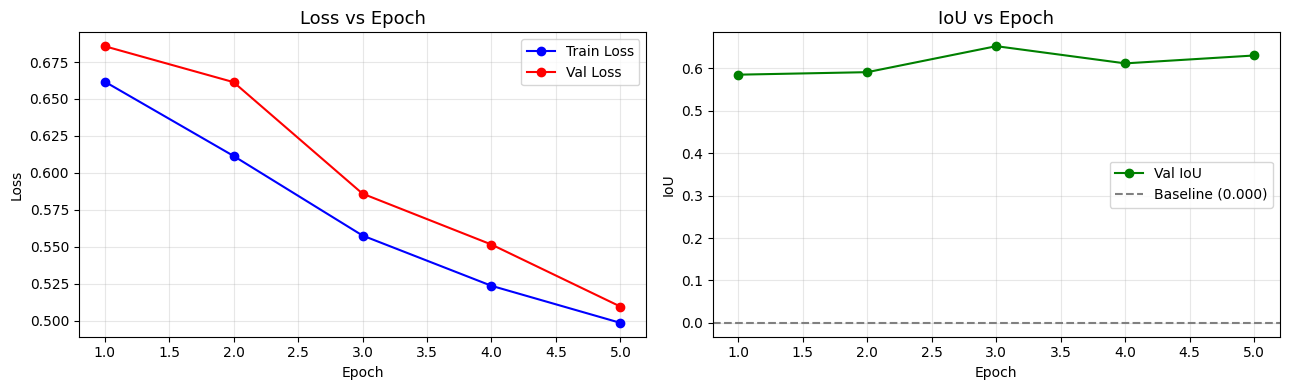

In [ ]:
# ===== Cell 12 =====
# Plot Loss and IoU curves

ep = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ep, history["train_loss"], "b-o", label="Train Loss")
ax1.plot(ep, history["val_loss"],   "r-o", label="Val Loss")
ax1.set_title("Loss vs Epoch", fontsize=13)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history["val_iou"], "g-o", label="Val IoU")
ax2.axhline(b_iou, color="gray", linestyle="--", label=f"Baseline ({b_iou:.3f})")
ax2.set_title("IoU vs Epoch", fontsize=13)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("IoU")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

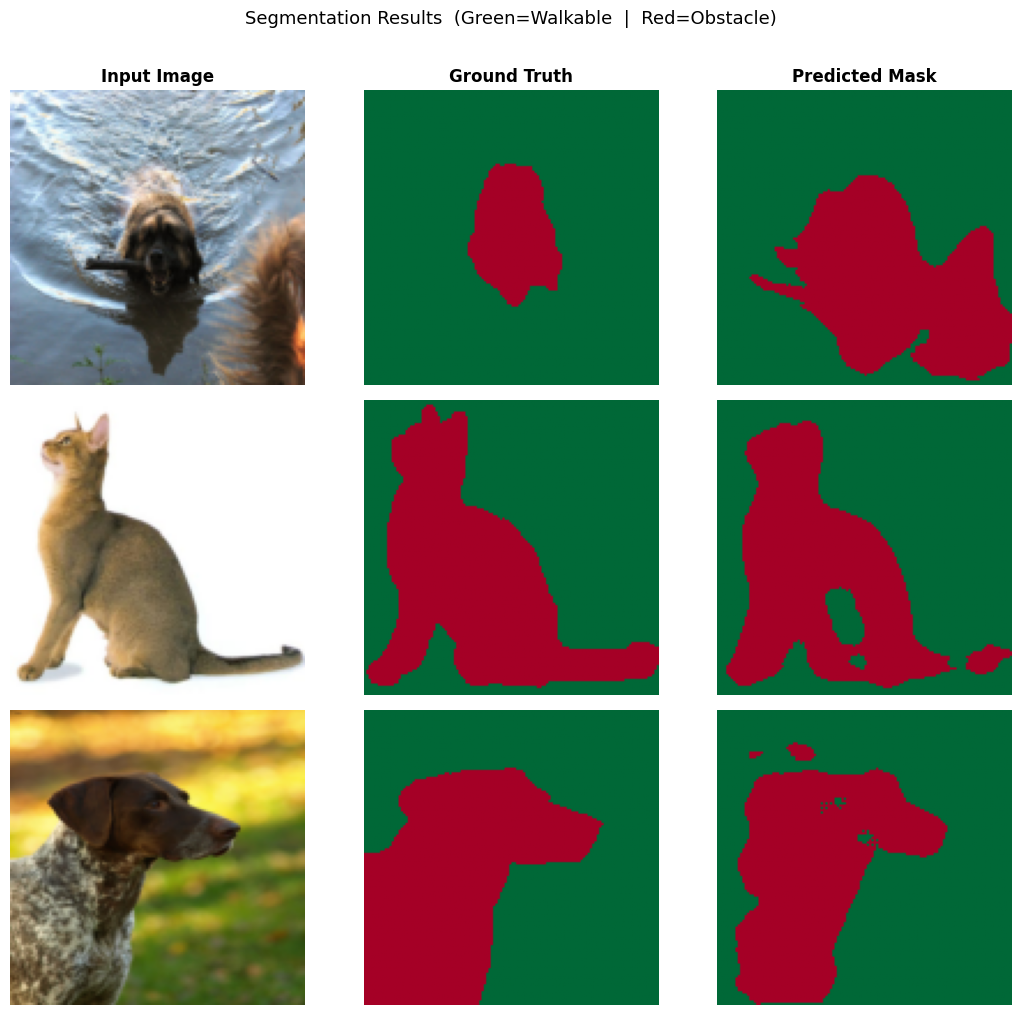

In [ ]:
# ===== Cell 13 =====
# Visualise predictions: Input | Ground Truth | Predicted Mask

def predict_mask(mdl, img_t):
    mdl.eval()
    with torch.no_grad():
        out = mdl(img_t.unsqueeze(0).to(device))
    return (torch.sigmoid(out) > 0.5).float().squeeze().cpu().numpy()

fig, axes = plt.subplots(3, 3, figsize=(11, 10))
for c, title in enumerate(["Input Image", "Ground Truth", "Predicted Mask"]):
    axes[0, c].set_title(title, fontsize=12, fontweight="bold")

for row in range(3):
    img_t, mask_t = full_ds[indices[row]]
    pred          = predict_mask(model, img_t)

    axes[row, 0].imshow(denorm(img_t)); axes[row, 0].axis("off")
    axes[row, 1].imshow(mask_t.squeeze().numpy(), cmap="RdYlGn", vmin=0, vmax=1)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(pred, cmap="RdYlGn", vmin=0, vmax=1)
    axes[row, 2].axis("off")

plt.suptitle("Segmentation Results  (Green=Walkable  |  Red=Obstacle)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()



In [ ]:
# ===== Cell 14 =====
# Navigation logic: split mask into 3 vertical strips -> LEFT / FORWARD / RIGHT

def get_direction(mask_np):
    H, W  = mask_np.shape
    t     = W // 3
    left  = mask_np[:, :t].sum()
    cen   = mask_np[:, t:2*t].sum()
    right = mask_np[:, 2*t:].sum()
    ratio = cen / (H * t + 1e-6)
    if ratio > 0.40:
        return "FORWARD"
    return "LEFT" if left >= right else "RIGHT"

# Demo on 5 samples
print("Navigation Direction Predictions:")
print("-" * 35)
for i in range(5):
    img_t, _ = full_ds[indices[i]]
    pred     = predict_mask(model, img_t)
    nav      = get_direction(pred)
    arrow    = {"FORWARD": "⬆", "LEFT": "⬅", "RIGHT": "➡"}[nav]
    print(f"  Sample {i+1}: {arrow} {nav}")


Navigation Direction Predictions:
-----------------------------------
  Sample 1: ⬆ FORWARD
  Sample 2: ⬆ FORWARD
  Sample 3: ⬆ FORWARD
  Sample 4: ⬅ LEFT
  Sample 5: ⬅ LEFT


In [ ]:
# ===== Cell 15 =====
# Save and reload model

torch.save(model.state_dict(), "model.pth")
print("Saved: model.pth")

loaded_model = SmallUNet().to(device)
loaded_model.load_state_dict(torch.load("model.pth", map_location=device))
loaded_model.eval()
print("Reloaded model from model.pth successfully.")


Saved: model.pth
Reloaded model from model.pth successfully.


In [ ]:
# ===== Cell 16 =====
# Voice output via pyttsx3 — silently skipped if audio is unavailable in Colab

def speak(text):
    try:
        import pyttsx3
        engine = pyttsx3.init()
        engine.setProperty("rate", 150)
        engine.say(f"Navigate {text}")
        engine.runAndWait()
        engine.stop()
        print(f"[Voice] Spoke: Navigate {text}")
    except Exception:
        print(f"[Voice] Audio unavailable. Direction: {text}")

speak("FORWARD")

[Voice] Audio unavailable. Direction: FORWARD


In [ ]:
# ===== Cell 17 =====
# Gradio UI
# Input : any uploaded image
# Output: coloured segmentation mask + navigation direction text

import gradio as gr

def gradio_predict(pil_image):
    img_t    = img_transform(pil_image.convert("RGB"))
    pred     = predict_mask(loaded_model, img_t)      # numpy [H, W]
    nav      = get_direction(pred)
    arrow    = {"FORWARD": "⬆", "LEFT": "⬅", "RIGHT": "➡"}[nav]

    # Speak direction (safe)
    speak(nav)

    # Build colour mask: green=walkable, red=obstacle
    rgb          = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    rgb[pred==1] = [0, 200, 0]
    rgb[pred==0] = [200, 0, 0]

    info = (
        f"Navigation: {arrow} {nav}\n"
        f"Walkable pixels : {int(pred.sum())} / {IMG_SIZE * IMG_SIZE} "
        f"({100 * pred.mean():.1f}%)"
    )
    return Image.fromarray(rgb), info

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Upload Scene Image"),
    outputs=[
        gr.Image(type="pil",  label="Segmentation Mask (Green=Safe, Red=Obstacle)"),
        gr.Textbox(           label="Navigation Direction"),
    ],
    title="Assistive Navigation — Walkable Region Detector",
    description=(
        "Upload any scene image. The U-Net segments walkable (green) vs obstacle (red) "
        "regions and recommends a navigation direction."
    ),
    allow_flagging="never",
)

demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://130823d7a3e1f8a7fa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
